# Hotel Booking Cancellation Prediction and Revenue Analysis Using Machine Learning

This notebook covers the full machine learning pipeline:
- Exploratory Data Analysis (EDA)
- Data Preprocessing and Feature Engineering
- Classification Models (Logistic Regression, Decision Tree, Random Forest, Naive Bayes, KNN, SVM, Neural Network)
- Model Evaluation and Comparison
- Hyperparameter Tuning
- PCA Dimensionality Reduction Experiment
- Optional Regression Task: ADR Prediction
- Final Conclusions and Business Recommendations

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, SVR
from sklearn.neural_network import MLPClassifier, MLPRegressor

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries imported successfully.')

Libraries imported successfully.


## 2. Load Dataset

In [2]:
df = pd.read_csv('hotel_bookings.csv')

print('Dataset loaded successfully.')
print(f'Shape: {df.shape}')

Dataset loaded successfully.
Shape: (119390, 32)


In [3]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [5]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


## 3. Missing Values and Duplicates

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

          Missing Count  Missing %
children              4   0.003350
country             488   0.408744
agent             16340  13.686238
company          112593  94.306893


In [7]:
print(f'Duplicate rows: {df.duplicated().sum()}')

Duplicate rows: 31994


## 4. Exploratory Data Analysis (EDA)

### 4.1 Cancellation Distribution

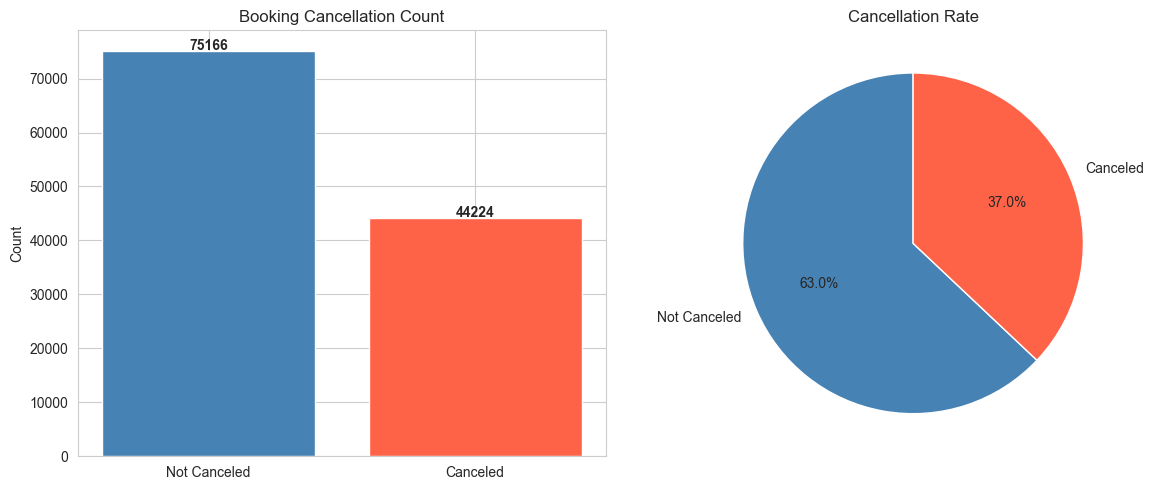

In [8]:
cancel_counts = df['is_canceled'].value_counts()
labels = ['Not Canceled', 'Canceled']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(labels, cancel_counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Booking Cancellation Count')
axes[0].set_ylabel('Count')
for i, v in enumerate(cancel_counts.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

axes[1].pie(cancel_counts.values, labels=labels, autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Cancellation Rate')

plt.tight_layout()
plt.show()

### 4.2 Cancellation by Hotel Type

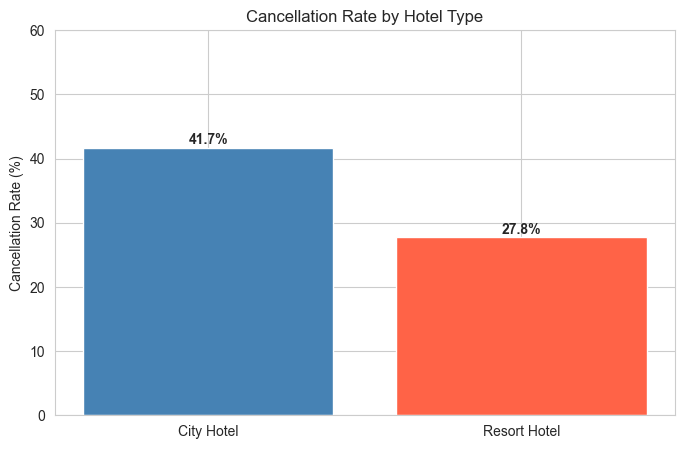

In [9]:
hotel_cancel = df.groupby('hotel')['is_canceled'].mean().reset_index()
hotel_cancel.columns = ['Hotel Type', 'Cancellation Rate']
hotel_cancel['Cancellation Rate'] = hotel_cancel['Cancellation Rate'] * 100

plt.figure(figsize=(8, 5))
plt.bar(hotel_cancel['Hotel Type'], hotel_cancel['Cancellation Rate'], color=['steelblue', 'tomato'])
plt.title('Cancellation Rate by Hotel Type')
plt.ylabel('Cancellation Rate (%)')
plt.ylim(0, 60)
for i, v in enumerate(hotel_cancel['Cancellation Rate']):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
plt.show()

### 4.3 Monthly Booking Trends

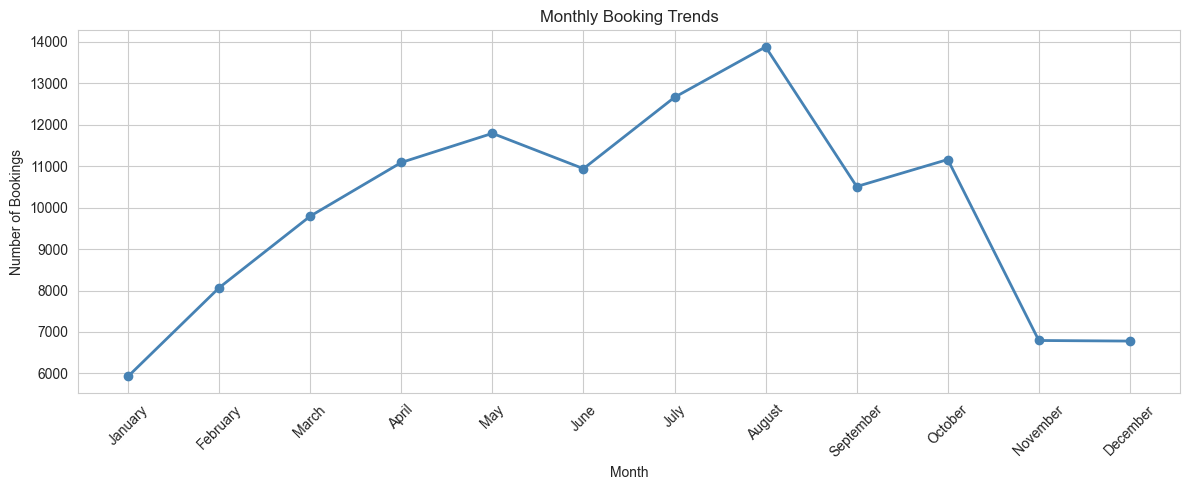

In [10]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

monthly = df.groupby('arrival_date_month').size().reindex(month_order)

plt.figure(figsize=(12, 5))
plt.plot(monthly.index, monthly.values, marker='o', color='steelblue', linewidth=2)
plt.title('Monthly Booking Trends')
plt.xlabel('Month')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4.4 Lead Time vs Cancellation

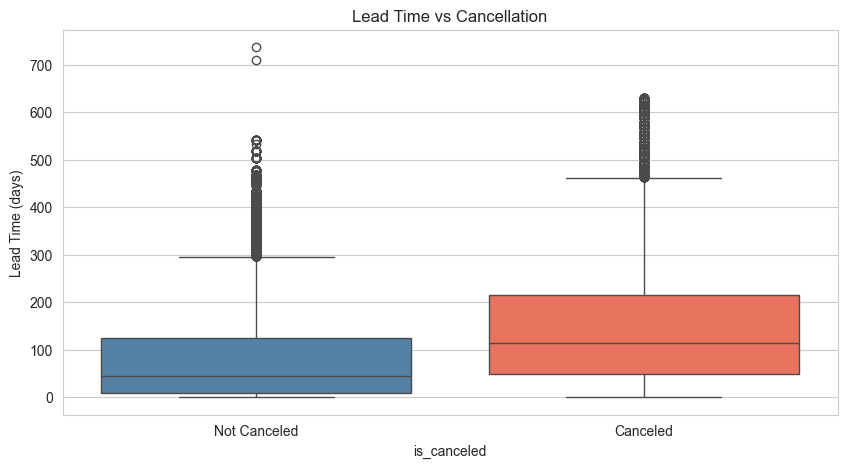

In [11]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='is_canceled', y='lead_time', data=df, palette=['steelblue', 'tomato'])
plt.xticks([0, 1], ['Not Canceled', 'Canceled'])
plt.title('Lead Time vs Cancellation')
plt.ylabel('Lead Time (days)')
plt.show()

### 4.5 Deposit Type vs Cancellation

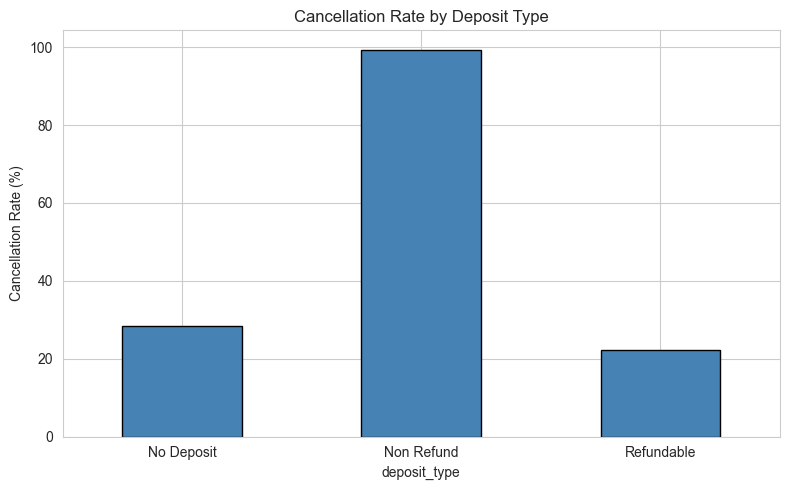

In [12]:
deposit_cancel = df.groupby('deposit_type')['is_canceled'].mean() * 100

plt.figure(figsize=(8, 5))
deposit_cancel.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Cancellation Rate by Deposit Type')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 4.6 Customer Type vs Cancellation

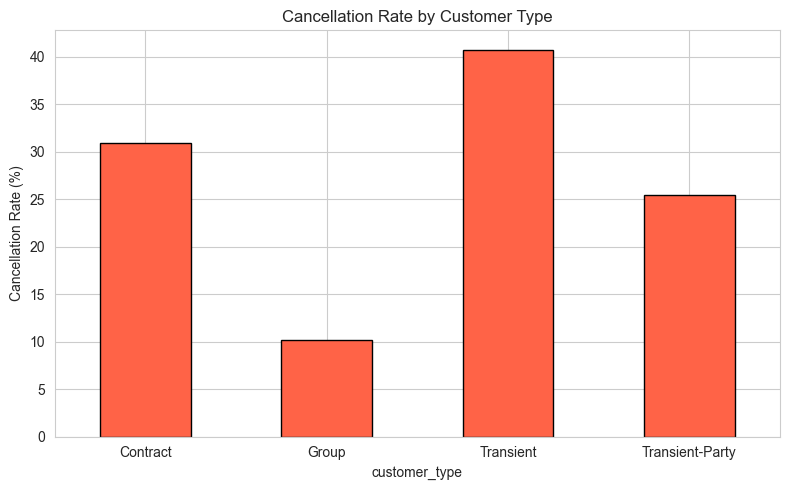

In [13]:
customer_cancel = df.groupby('customer_type')['is_canceled'].mean() * 100

plt.figure(figsize=(8, 5))
customer_cancel.plot(kind='bar', color='tomato', edgecolor='black')
plt.title('Cancellation Rate by Customer Type')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 4.7 ADR Distribution

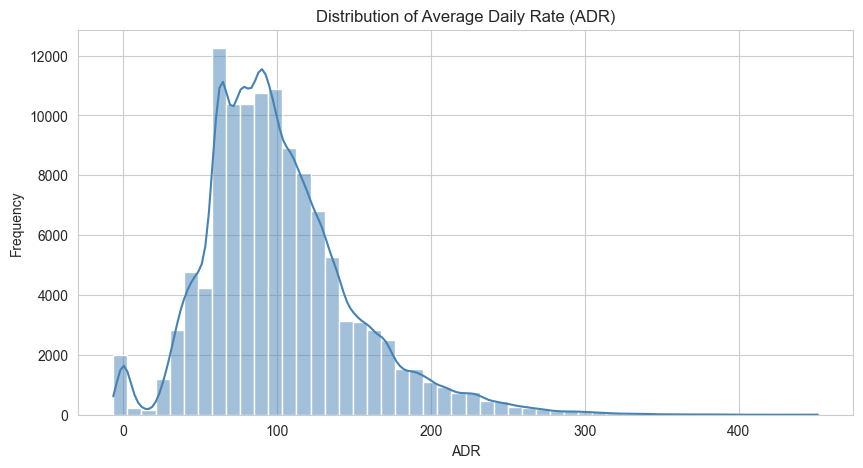

In [14]:
plt.figure(figsize=(10, 5))
sns.histplot(df[df['adr'] < 500]['adr'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of Average Daily Rate (ADR)')
plt.xlabel('ADR')
plt.ylabel('Frequency')
plt.show()

### 4.8 Correlation Heatmap

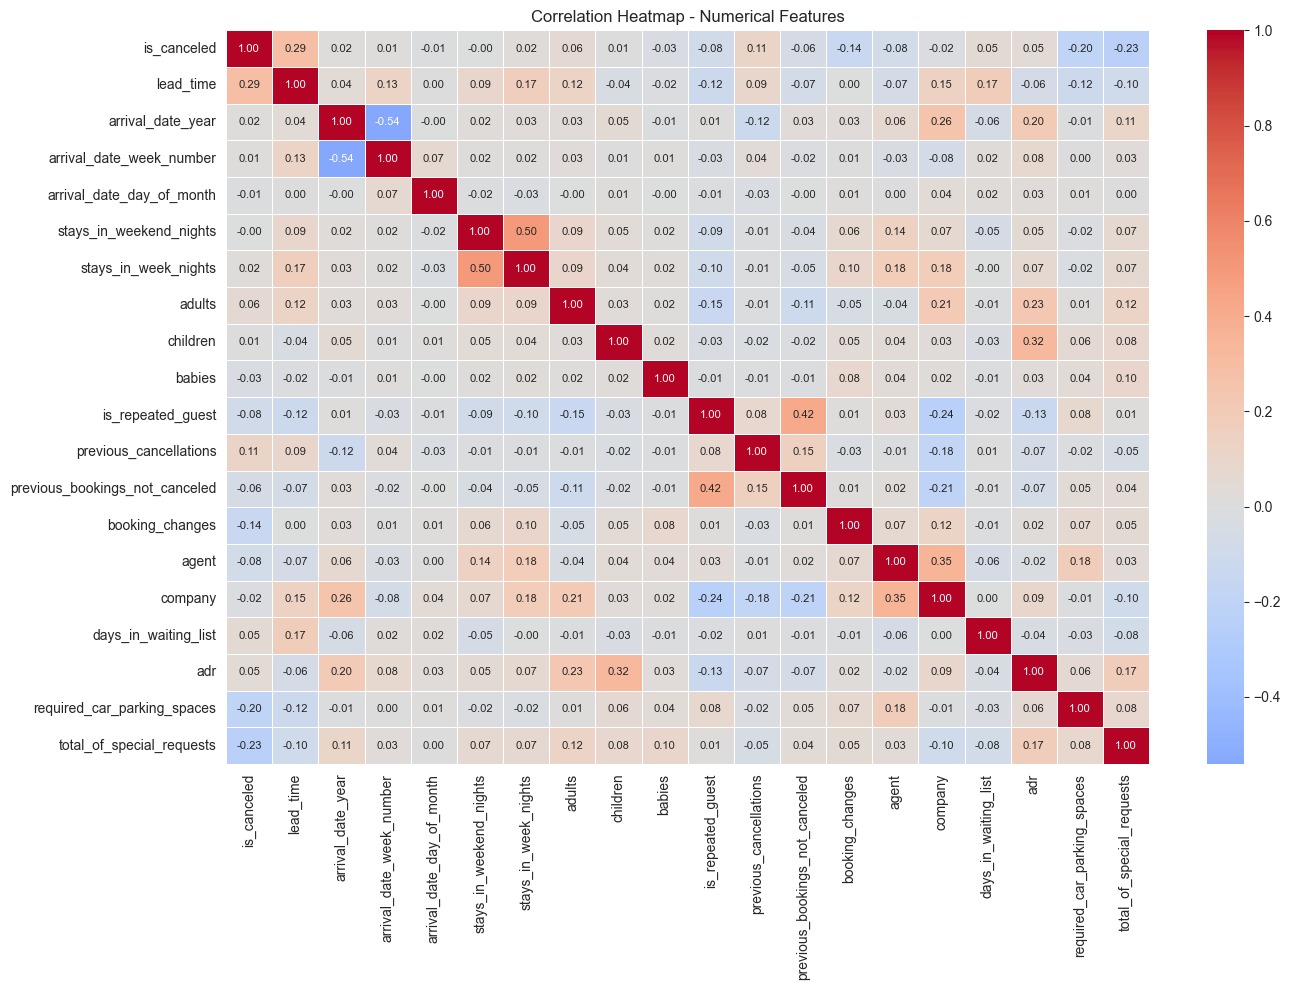

In [15]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Heatmap - Numerical Features')
plt.tight_layout()
plt.show()

### 4.9 Special Requests vs Cancellation

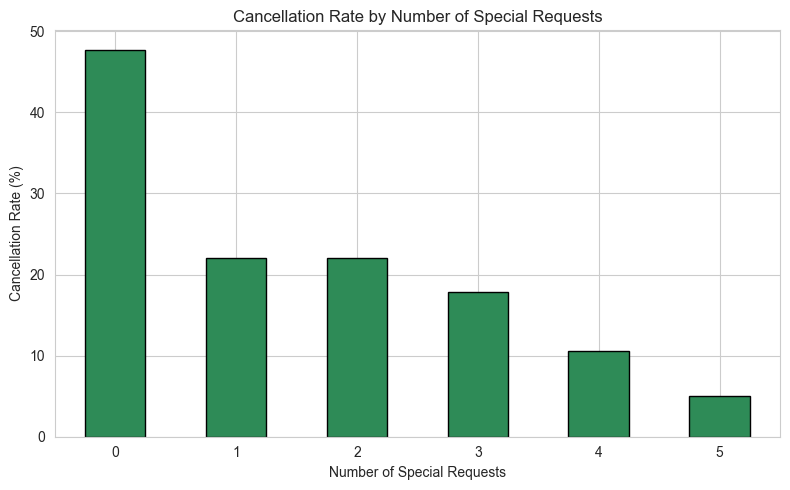

In [16]:
special_cancel = df.groupby('total_of_special_requests')['is_canceled'].mean() * 100

plt.figure(figsize=(8, 5))
special_cancel.plot(kind='bar', color='seagreen', edgecolor='black')
plt.title('Cancellation Rate by Number of Special Requests')
plt.xlabel('Number of Special Requests')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Data Cleaning

In [17]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)
print(f'Shape after removing duplicates: {df.shape}')

Shape after removing duplicates: (87396, 32)


In [18]:
# Handle missing values
# 'children' - fill with 0 (no children assumed)
df['children'] = df['children'].fillna(0)

# 'country' - fill with mode (most frequent country)
df['country'] = df['country'].fillna(df['country'].mode()[0])

# 'agent' - fill NULL string with 0 (no agent)
df['agent'] = df['agent'].replace('NULL', 0).fillna(0)

# 'company' - fill NULL string with 0 (no company)
df['company'] = df['company'].replace('NULL', 0).fillna(0)

print('Missing values after handling:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print('No missing values remain.')

Missing values after handling:
Series([], dtype: int64)
No missing values remain.


In [19]:
# Handle outliers in ADR
# Remove rows where ADR is negative or extremely high
print(f'Rows before ADR outlier removal: {len(df)}')
df = df[(df['adr'] >= 0) & (df['adr'] <= 5000)]
print(f'Rows after ADR outlier removal: {len(df)}')

Rows before ADR outlier removal: 87396
Rows after ADR outlier removal: 87394


In [20]:
# Remove bookings with zero adults, children, and babies (invalid records)
df = df[~((df['adults'] == 0) & (df['children'] == 0) & (df['babies'] == 0))]
print(f'Shape after removing invalid guest records: {df.shape}')

Shape after removing invalid guest records: (87228, 32)


In [21]:
# Remove leakage columns that reveal the outcome
df.drop(columns=['reservation_status', 'reservation_status_date'], inplace=True)
print('Leakage columns removed: reservation_status, reservation_status_date')

Leakage columns removed: reservation_status, reservation_status_date


## 6. Feature Engineering

In [22]:
# Total nights stayed
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

# Total number of guests
df['total_guests'] = df['adults'] + df['children'] + df['babies']

# Whether the customer had previous cancellations
df['has_previous_cancellation'] = (df['previous_cancellations'] > 0).astype(int)

# Whether the booking is a family booking (includes children or babies)
df['is_family_booking'] = ((df['children'] > 0) | (df['babies'] > 0)).astype(int)

# Booking season based on arrival month
season_map = {
    'December': 'Winter', 'January': 'Winter', 'February': 'Winter',
    'March': 'Spring', 'April': 'Spring', 'May': 'Spring',
    'June': 'Summer', 'July': 'Summer', 'August': 'Summer',
    'September': 'Autumn', 'October': 'Autumn', 'November': 'Autumn'
}
df['booking_season'] = df['arrival_date_month'].map(season_map)

# Whether the customer made at least one special request
df['has_special_request'] = (df['total_of_special_requests'] > 0).astype(int)

print('New features created:')
print(['total_nights', 'total_guests', 'has_previous_cancellation',
       'is_family_booking', 'booking_season', 'has_special_request'])

New features created:
['total_nights', 'total_guests', 'has_previous_cancellation', 'is_family_booking', 'booking_season', 'has_special_request']


## 7. Encoding Categorical Features

In [23]:
# Identify categorical columns to encode
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f'Categorical columns: {cat_cols}')

Categorical columns: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'booking_season']


In [24]:
# Apply Label Encoding to all categorical columns
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print('Label encoding applied to all categorical columns.')
print(f'Dataset shape after encoding: {df.shape}')

Label encoding applied to all categorical columns.
Dataset shape after encoding: (87228, 36)


## 8. Prepare Data for Modeling

In [25]:
# Separate features and target for classification
X = df.drop(columns=['is_canceled', 'adr'])
y_class = df['is_canceled']
y_reg = df['adr']

print(f'Feature matrix shape: {X.shape}')
print(f'Classification target shape: {y_class.shape}')
print(f'Regression target shape: {y_reg.shape}')

Feature matrix shape: (87228, 34)
Classification target shape: (87228,)
Regression target shape: (87228,)


In [26]:
# Split into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

print(f'Training set size: {X_train.shape}')
print(f'Test set size: {X_test.shape}')

Training set size: (69782, 34)
Test set size: (17446, 34)


In [27]:
# Scale features for models that are sensitive to scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Features scaled using StandardScaler.')

Features scaled using StandardScaler.


## 9. Train Classification Models

In [28]:
# Helper function to evaluate a classification model
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec = recall_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    cv = cross_val_score(model, X_tr, y_tr, cv=5, scoring='accuracy').mean()
    print(f'--- {name} ---')
    print(f'Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | CV Acc: {cv:.4f}')
    return {'Model': name, 'Accuracy': acc, 'Precision': prec,
            'Recall': rec, 'F1-Score': f1, 'CV Accuracy': cv}, y_pred

### 9.1 Logistic Regression

In [29]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_result, lr_pred = evaluate_model('Logistic Regression', lr_model,
                                    X_train_scaled, X_test_scaled, y_train, y_test)
print(classification_report(y_test, lr_pred, target_names=['Not Canceled', 'Canceled']))

--- Logistic Regression ---
Accuracy: 0.7764 | Precision: 0.6678 | Recall: 0.3734 | F1: 0.4790 | CV Acc: 0.7754
              precision    recall  f1-score   support

Not Canceled       0.80      0.93      0.86     12644
    Canceled       0.67      0.37      0.48      4802

    accuracy                           0.78     17446
   macro avg       0.73      0.65      0.67     17446
weighted avg       0.76      0.78      0.75     17446



### 9.2 Decision Tree

In [30]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_result, dt_pred = evaluate_model('Decision Tree', dt_model,
                                    X_train, X_test, y_train, y_test)
print(classification_report(y_test, dt_pred, target_names=['Not Canceled', 'Canceled']))

--- Decision Tree ---
Accuracy: 0.7997 | Precision: 0.6304 | Recall: 0.6579 | F1: 0.6438 | CV Acc: 0.7973
              precision    recall  f1-score   support

Not Canceled       0.87      0.85      0.86     12644
    Canceled       0.63      0.66      0.64      4802

    accuracy                           0.80     17446
   macro avg       0.75      0.76      0.75     17446
weighted avg       0.80      0.80      0.80     17446



### 9.3 Random Forest

In [31]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_result, rf_pred = evaluate_model('Random Forest', rf_model,
                                    X_train, X_test, y_train, y_test)
print(classification_report(y_test, rf_pred, target_names=['Not Canceled', 'Canceled']))

--- Random Forest ---
Accuracy: 0.8503 | Precision: 0.7720 | Recall: 0.6474 | F1: 0.7043 | CV Acc: 0.8453
              precision    recall  f1-score   support

Not Canceled       0.87      0.93      0.90     12644
    Canceled       0.77      0.65      0.70      4802

    accuracy                           0.85     17446
   macro avg       0.82      0.79      0.80     17446
weighted avg       0.85      0.85      0.85     17446



### 9.4 Naive Bayes

In [32]:
nb_model = GaussianNB()
nb_result, nb_pred = evaluate_model('Naive Bayes', nb_model,
                                    X_train_scaled, X_test_scaled, y_train, y_test)
print(classification_report(y_test, nb_pred, target_names=['Not Canceled', 'Canceled']))

--- Naive Bayes ---
Accuracy: 0.4184 | Precision: 0.3183 | Recall: 0.9748 | F1: 0.4799 | CV Acc: 0.4129
              precision    recall  f1-score   support

Not Canceled       0.96      0.21      0.34     12644
    Canceled       0.32      0.97      0.48      4802

    accuracy                           0.42     17446
   macro avg       0.64      0.59      0.41     17446
weighted avg       0.78      0.42      0.38     17446



### 9.5 K-Nearest Neighbors

In [33]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_result, knn_pred = evaluate_model('KNN', knn_model,
                                      X_train_scaled, X_test_scaled, y_train, y_test)
print(classification_report(y_test, knn_pred, target_names=['Not Canceled', 'Canceled']))

--- KNN ---
Accuracy: 0.7906 | Precision: 0.6319 | Recall: 0.5731 | F1: 0.6011 | CV Acc: 0.7816
              precision    recall  f1-score   support

Not Canceled       0.84      0.87      0.86     12644
    Canceled       0.63      0.57      0.60      4802

    accuracy                           0.79     17446
   macro avg       0.74      0.72      0.73     17446
weighted avg       0.79      0.79      0.79     17446



### 9.6 Support Vector Machine

In [34]:
# Use a subset for SVM due to computational cost
svm_sample = 15000
X_tr_svm = X_train_scaled[:svm_sample]
y_tr_svm = y_train.iloc[:svm_sample]

svm_model = SVC(kernel='rbf', C=1.0, random_state=42)
svm_model.fit(X_tr_svm, y_tr_svm)
svm_pred = svm_model.predict(X_test_scaled)

svm_result = {
    'Model': 'SVM',
    'Accuracy': accuracy_score(y_test, svm_pred),
    'Precision': precision_score(y_test, svm_pred),
    'Recall': recall_score(y_test, svm_pred),
    'F1-Score': f1_score(y_test, svm_pred),
    'CV Accuracy': cross_val_score(SVC(kernel='rbf', C=1.0, random_state=42),
                                   X_tr_svm, y_tr_svm, cv=3, scoring='accuracy').mean()
}
print('--- SVM ---')
for k, v in svm_result.items():
    if k != 'Model':
        print(f'{k}: {v:.4f}')
print(classification_report(y_test, svm_pred, target_names=['Not Canceled', 'Canceled']))

--- SVM ---
Accuracy: 0.8048
Precision: 0.7348
Recall: 0.4552
F1-Score: 0.5622
CV Accuracy: 0.7969
              precision    recall  f1-score   support

Not Canceled       0.82      0.94      0.87     12644
    Canceled       0.73      0.46      0.56      4802

    accuracy                           0.80     17446
   macro avg       0.78      0.70      0.72     17446
weighted avg       0.80      0.80      0.79     17446



### 9.7 Neural Network (MLP)

In [35]:
mlp_model = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=200,
                          activation='relu', random_state=42)
mlp_result, mlp_pred = evaluate_model('Neural Network', mlp_model,
                                      X_train_scaled, X_test_scaled, y_train, y_test)
print(classification_report(y_test, mlp_pred, target_names=['Not Canceled', 'Canceled']))

--- Neural Network ---
Accuracy: 0.8153 | Precision: 0.6986 | Recall: 0.5787 | F1: 0.6330 | CV Acc: 0.8065
              precision    recall  f1-score   support

Not Canceled       0.85      0.91      0.88     12644
    Canceled       0.70      0.58      0.63      4802

    accuracy                           0.82     17446
   macro avg       0.77      0.74      0.75     17446
weighted avg       0.81      0.82      0.81     17446



## 10. Model Comparison

In [36]:
results = pd.DataFrame([lr_result, dt_result, rf_result, nb_result,
                        knn_result, svm_result, mlp_result])
results = results.sort_values('Accuracy', ascending=False).reset_index(drop=True)
print('Classification Model Comparison:')
print(results.to_string(index=False, float_format='{:.4f}'.format))

Classification Model Comparison:
              Model  Accuracy  Precision  Recall  F1-Score  CV Accuracy
      Random Forest    0.8503     0.7720  0.6474    0.7043       0.8453
     Neural Network    0.8153     0.6986  0.5787    0.6330       0.8065
                SVM    0.8048     0.7348  0.4552    0.5622       0.7969
      Decision Tree    0.7997     0.6304  0.6579    0.6438       0.7973
                KNN    0.7906     0.6319  0.5731    0.6011       0.7816
Logistic Regression    0.7764     0.6678  0.3734    0.4790       0.7754
        Naive Bayes    0.4184     0.3183  0.9748    0.4799       0.4129


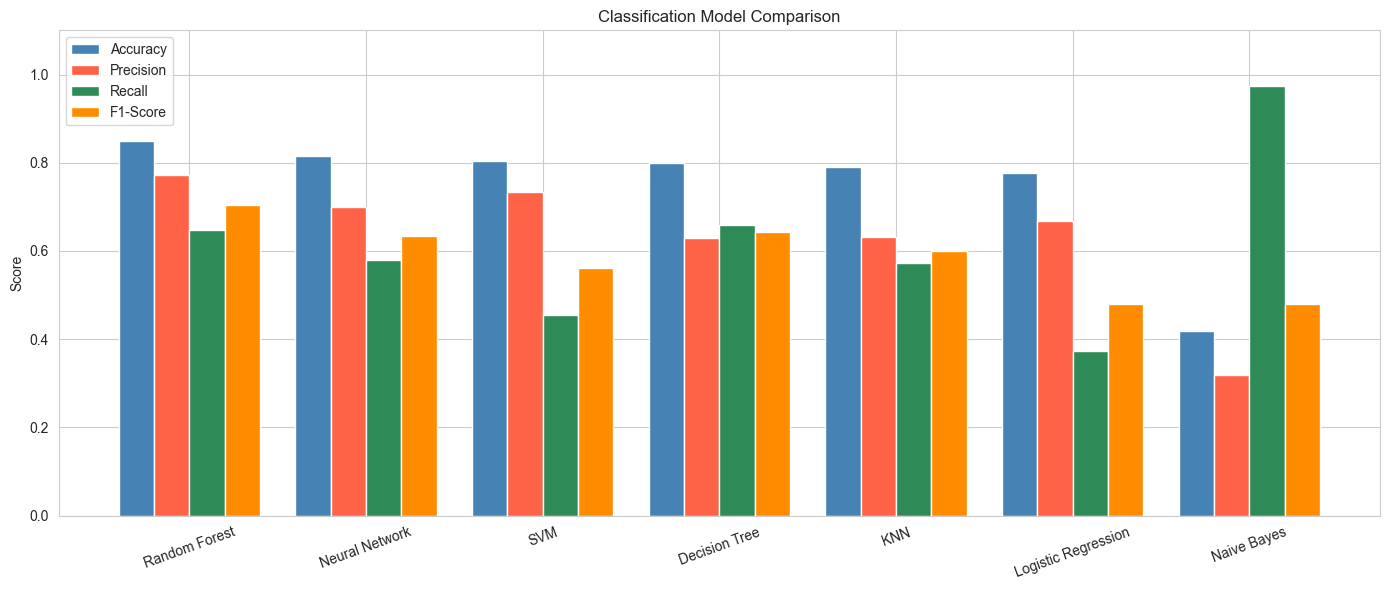

In [37]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(results['Model']))
width = 0.2
colors = ['steelblue', 'tomato', 'seagreen', 'darkorange']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i * width, results[metric], width, label=metric, color=color)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results['Model'], rotation=20)
ax.set_ylim(0, 1.1)
ax.set_title('Classification Model Comparison')
ax.set_ylabel('Score')
ax.legend()
plt.tight_layout()
plt.show()

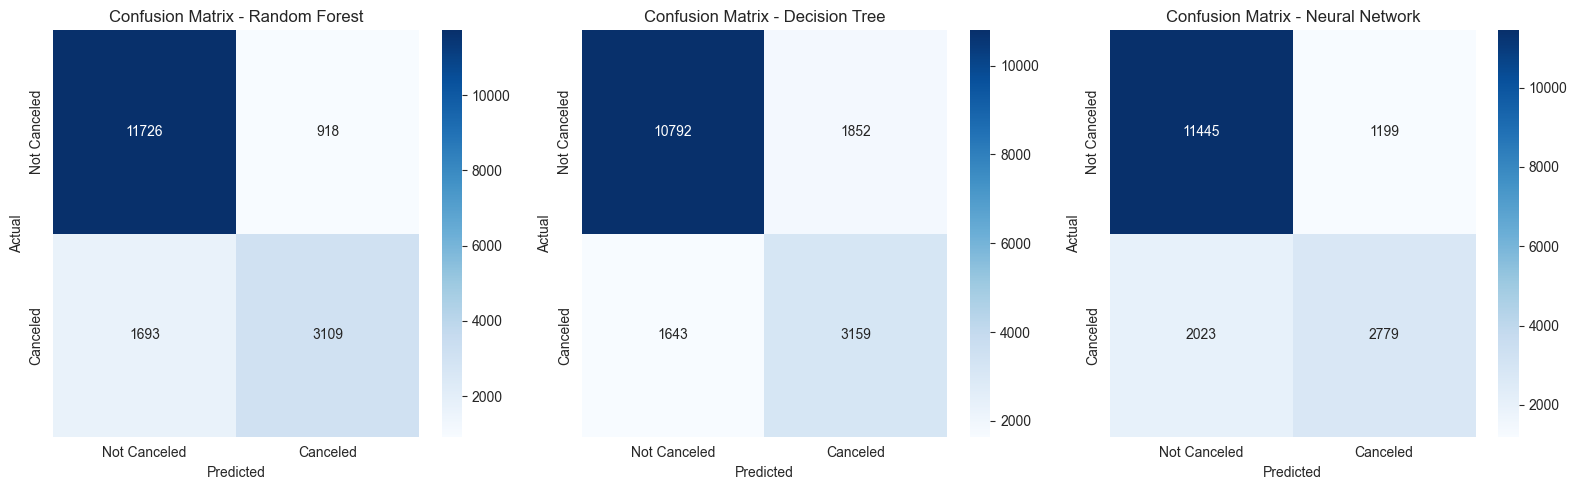

In [38]:
# Confusion matrices for the top 3 models
top_preds = {
    'Random Forest': rf_pred,
    'Decision Tree': dt_pred,
    'Neural Network': mlp_pred
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, pred) in zip(axes, top_preds.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Canceled', 'Canceled'],
                yticklabels=['Not Canceled', 'Canceled'])
    ax.set_title(f'Confusion Matrix - {name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 11. Feature Importance (Random Forest)

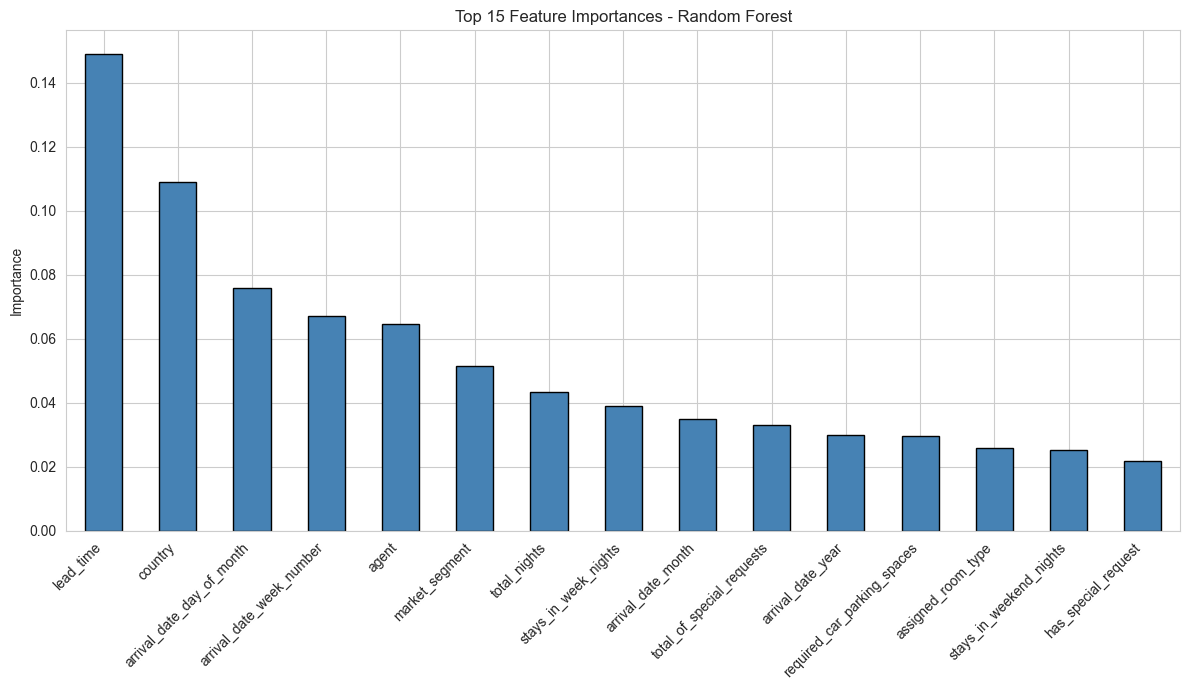

In [39]:
feature_names = X.columns.tolist()
importances = rf_model.feature_importances_
feature_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(12, 7))
feature_imp.head(15).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 15 Feature Importances - Random Forest')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 12. Hyperparameter Tuning

### 12.1 Decision Tree Tuning

In [40]:
dt_params = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
                       dt_params, cv=5, scoring='f1', n_jobs=-1)
dt_grid.fit(X_train, y_train)

print(f'Best parameters (Decision Tree): {dt_grid.best_params_}')
dt_best_pred = dt_grid.predict(X_test)
print(f'Tuned Decision Tree Accuracy: {accuracy_score(y_test, dt_best_pred):.4f}')
print(f'Tuned Decision Tree F1-Score: {f1_score(y_test, dt_best_pred):.4f}')

Best parameters (Decision Tree): {'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 2}
Tuned Decision Tree Accuracy: 0.8300
Tuned Decision Tree F1-Score: 0.6741


### 12.2 Random Forest Tuning

In [41]:
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf_rand = RandomizedSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1),
                              rf_params, n_iter=10, cv=3,
                              scoring='f1', random_state=42, n_jobs=-1)
rf_rand.fit(X_train, y_train)

print(f'Best parameters (Random Forest): {rf_rand.best_params_}')
rf_best_pred = rf_rand.predict(X_test)
print(f'Tuned Random Forest Accuracy: {accuracy_score(y_test, rf_best_pred):.4f}')
print(f'Tuned Random Forest F1-Score: {f1_score(y_test, rf_best_pred):.4f}')

Best parameters (Random Forest): {'n_estimators': 200, 'min_samples_split': 2, 'max_depth': None}
Tuned Random Forest Accuracy: 0.8501
Tuned Random Forest F1-Score: 0.7044


### 12.3 KNN Tuning

In [42]:
knn_params = {
    'n_neighbors': [3, 5, 7, 10, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=3,
                        scoring='f1', n_jobs=-1)
knn_grid.fit(X_train_scaled, y_train)

print(f'Best parameters (KNN): {knn_grid.best_params_}')
knn_best_pred = knn_grid.predict(X_test_scaled)
print(f'Tuned KNN Accuracy: {accuracy_score(y_test, knn_best_pred):.4f}')
print(f'Tuned KNN F1-Score: {f1_score(y_test, knn_best_pred):.4f}')

Best parameters (KNN): {'metric': 'manhattan', 'n_neighbors': 10, 'weights': 'distance'}
Tuned KNN Accuracy: 0.8036
Tuned KNN F1-Score: 0.6199


In [43]:
# Tuning comparison summary
tuning_results = pd.DataFrame([
    {'Model': 'Decision Tree (Baseline)', 'Accuracy': accuracy_score(y_test, dt_pred), 'F1': f1_score(y_test, dt_pred)},
    {'Model': 'Decision Tree (Tuned)', 'Accuracy': accuracy_score(y_test, dt_best_pred), 'F1': f1_score(y_test, dt_best_pred)},
    {'Model': 'Random Forest (Baseline)', 'Accuracy': accuracy_score(y_test, rf_pred), 'F1': f1_score(y_test, rf_pred)},
    {'Model': 'Random Forest (Tuned)', 'Accuracy': accuracy_score(y_test, rf_best_pred), 'F1': f1_score(y_test, rf_best_pred)},
    {'Model': 'KNN (Baseline)', 'Accuracy': accuracy_score(y_test, knn_pred), 'F1': f1_score(y_test, knn_pred)},
    {'Model': 'KNN (Tuned)', 'Accuracy': accuracy_score(y_test, knn_best_pred), 'F1': f1_score(y_test, knn_best_pred)},
])
print('Hyperparameter Tuning Results:')
print(tuning_results.to_string(index=False, float_format='{:.4f}'.format))

Hyperparameter Tuning Results:
                   Model  Accuracy     F1
Decision Tree (Baseline)    0.7997 0.6438
   Decision Tree (Tuned)    0.8300 0.6741
Random Forest (Baseline)    0.8503 0.7043
   Random Forest (Tuned)    0.8501 0.7044
          KNN (Baseline)    0.7906 0.6011
             KNN (Tuned)    0.8036 0.6199


## 13. PCA Experiment

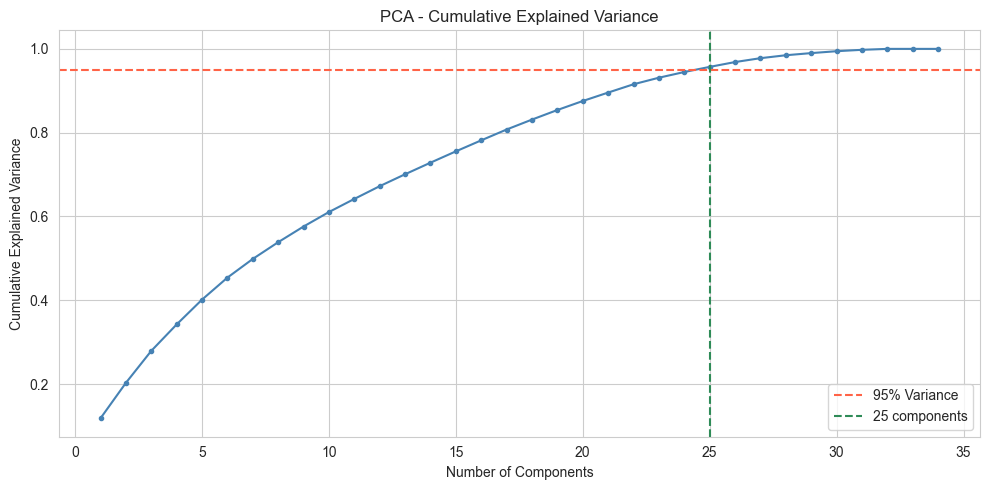

Components needed for 95% variance: 25


In [44]:
# Apply PCA and check explained variance
pca_full = PCA(random_state=42)
pca_full.fit(X_train_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_95 = np.argmax(cumvar >= 0.95) + 1

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumvar) + 1), cumvar, marker='.', color='steelblue')
plt.axhline(y=0.95, color='tomato', linestyle='--', label='95% Variance')
plt.axvline(x=n_95, color='seagreen', linestyle='--', label=f'{n_95} components')
plt.title('PCA - Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.tight_layout()
plt.show()
print(f'Components needed for 95% variance: {n_95}')

In [45]:
# Apply PCA with selected number of components
pca = PCA(n_components=n_95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f'Original feature count: {X_train_scaled.shape[1]}')
print(f'PCA reduced feature count: {X_train_pca.shape[1]}')

Original feature count: 34
PCA reduced feature count: 25


In [46]:
# Train Logistic Regression on PCA-reduced data
lr_pca = LogisticRegression(max_iter=1000, random_state=42)
lr_pca.fit(X_train_pca, y_train)
lr_pca_pred = lr_pca.predict(X_test_pca)

# Train Random Forest on PCA-reduced data
rf_pca = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_pca.fit(X_train_pca, y_train)
rf_pca_pred = rf_pca.predict(X_test_pca)

# PCA comparison table
pca_comparison = pd.DataFrame([
    {'Model': 'Logistic Regression (Original)',
     'Accuracy': accuracy_score(y_test, lr_pred),
     'F1-Score': f1_score(y_test, lr_pred)},
    {'Model': 'Logistic Regression (PCA)',
     'Accuracy': accuracy_score(y_test, lr_pca_pred),
     'F1-Score': f1_score(y_test, lr_pca_pred)},
    {'Model': 'Random Forest (Original)',
     'Accuracy': accuracy_score(y_test, rf_pred),
     'F1-Score': f1_score(y_test, rf_pred)},
    {'Model': 'Random Forest (PCA)',
     'Accuracy': accuracy_score(y_test, rf_pca_pred),
     'F1-Score': f1_score(y_test, rf_pca_pred)},
])

print('PCA Experiment Results:')
print(pca_comparison.to_string(index=False, float_format='{:.4f}'.format))

PCA Experiment Results:
                         Model  Accuracy  F1-Score
Logistic Regression (Original)    0.7764    0.4790
     Logistic Regression (PCA)    0.7657    0.4117
      Random Forest (Original)    0.8503    0.7043
           Random Forest (PCA)    0.8120    0.5930


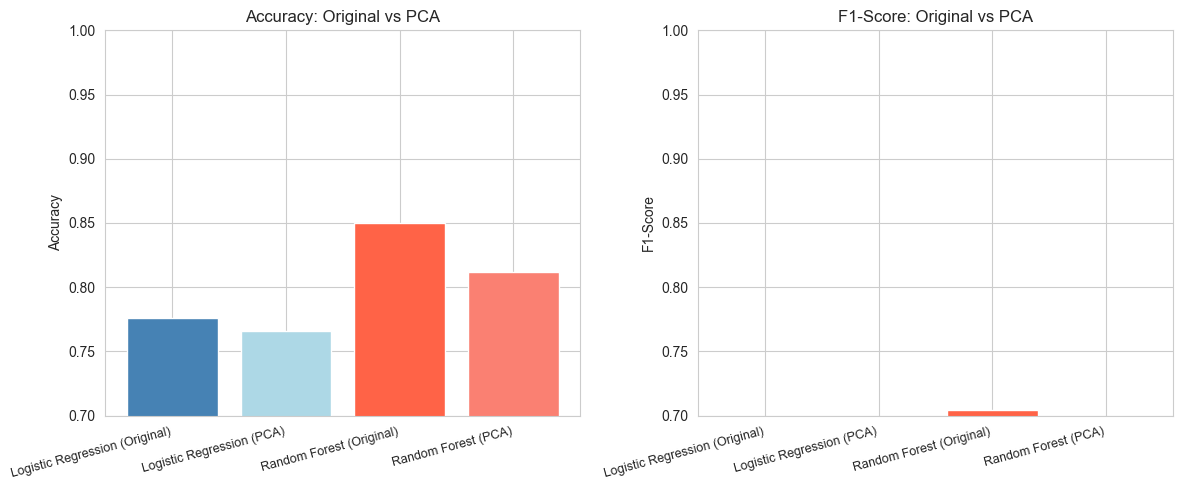

In [47]:
# Bar chart comparing PCA vs original performance
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, metric in zip(axes, ['Accuracy', 'F1-Score']):
    ax.bar(pca_comparison['Model'], pca_comparison[metric],
           color=['steelblue', 'lightblue', 'tomato', 'salmon'])
    ax.set_title(f'{metric}: Original vs PCA')
    ax.set_ylabel(metric)
    ax.set_ylim(0.7, 1.0)
    ax.set_xticklabels(pca_comparison['Model'], rotation=15, ha='right', fontsize=9)

plt.tight_layout()
plt.show()

## 14. Optional Regression Task: ADR Prediction

In [48]:
# Split for regression task
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

scaler_r = StandardScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled = scaler_r.transform(X_test_r)

print(f'Regression training set size: {X_train_r.shape}')

Regression training set size: (69782, 34)


In [49]:
# Helper function to evaluate regression models
def evaluate_regression(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    mae = mean_absolute_error(y_te, y_pred)
    mse = mean_squared_error(y_te, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_te, y_pred)
    print(f'--- {name} ---')
    print(f'MAE: {mae:.4f} | MSE: {mse:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}')
    return {'Model': name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2 Score': r2}, y_pred

In [50]:
# Linear Regression
lin_reg_model = LinearRegression()
lin_reg_result, lin_reg_pred = evaluate_regression('Linear Regression', lin_reg_model,
                                                   X_train_r_scaled, X_test_r_scaled,
                                                   y_train_r, y_test_r)

--- Linear Regression ---
MAE: 30.0238 | MSE: 1639.2786 | RMSE: 40.4880 | R2: 0.4047


In [51]:
# Random Forest Regressor
rf_reg_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg_result, rf_reg_pred = evaluate_regression('Random Forest Regressor', rf_reg_model,
                                                  X_train_r, X_test_r, y_train_r, y_test_r)

--- Random Forest Regressor ---
MAE: 9.4734 | MSE: 296.9692 | RMSE: 17.2328 | R2: 0.8922


In [52]:
# Support Vector Regressor (on a subset due to computational cost)
svr_sample = 10000
svr_model = SVR(kernel='rbf', C=1.0)
svr_model.fit(X_train_r_scaled[:svr_sample], y_train_r.iloc[:svr_sample])
svr_pred = svr_model.predict(X_test_r_scaled)

svr_result = {
    'Model': 'SVR',
    'MAE': mean_absolute_error(y_test_r, svr_pred),
    'MSE': mean_squared_error(y_test_r, svr_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test_r, svr_pred)),
    'R2 Score': r2_score(y_test_r, svr_pred)
}
print('--- SVR ---')
for k, v in svr_result.items():
    if k != 'Model':
        print(f'{k}: {v:.4f}')

--- SVR ---
MAE: 28.4100
MSE: 1674.6704
RMSE: 40.9227
R2 Score: 0.3919


In [53]:
# Neural Network Regressor
mlp_reg_model = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=200, random_state=42)
mlp_reg_result, mlp_reg_pred = evaluate_regression('Neural Network Regressor', mlp_reg_model,
                                                    X_train_r_scaled, X_test_r_scaled,
                                                    y_train_r, y_test_r)

--- Neural Network Regressor ---
MAE: 13.5755 | MSE: 410.7698 | RMSE: 20.2675 | R2: 0.8508


In [54]:
# Regression model comparison table
reg_results = pd.DataFrame([lin_reg_result, rf_reg_result, svr_result, mlp_reg_result])
reg_results = reg_results.sort_values('R2 Score', ascending=False).reset_index(drop=True)
print('Regression Model Comparison (ADR Prediction):')
print(reg_results.to_string(index=False, float_format='{:.4f}'.format))

Regression Model Comparison (ADR Prediction):
                   Model     MAE       MSE    RMSE  R2 Score
 Random Forest Regressor  9.4734  296.9692 17.2328    0.8922
Neural Network Regressor 13.5755  410.7698 20.2675    0.8508
       Linear Regression 30.0238 1639.2786 40.4880    0.4047
                     SVR 28.4100 1674.6704 40.9227    0.3919


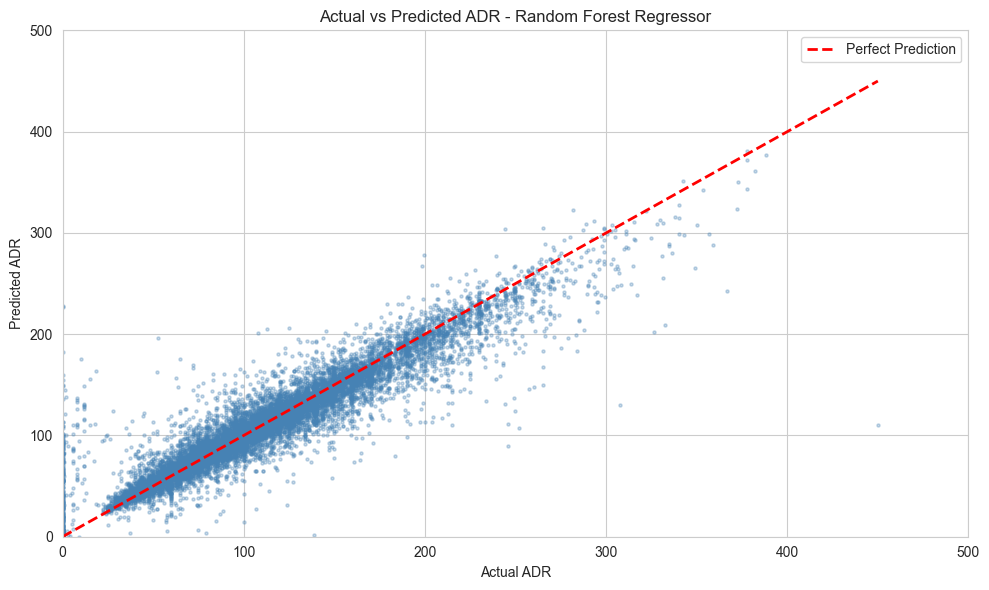

In [55]:
# Actual vs Predicted ADR plot for the best regression model
best_reg_pred = rf_reg_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_test_r, best_reg_pred, alpha=0.3, color='steelblue', s=5)
plt.plot([y_test_r.min(), y_test_r.max()],
         [y_test_r.min(), y_test_r.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.title('Actual vs Predicted ADR - Random Forest Regressor')
plt.xlabel('Actual ADR')
plt.ylabel('Predicted ADR')
plt.legend()
plt.xlim(0, 500)
plt.ylim(0, 500)
plt.tight_layout()
plt.show()

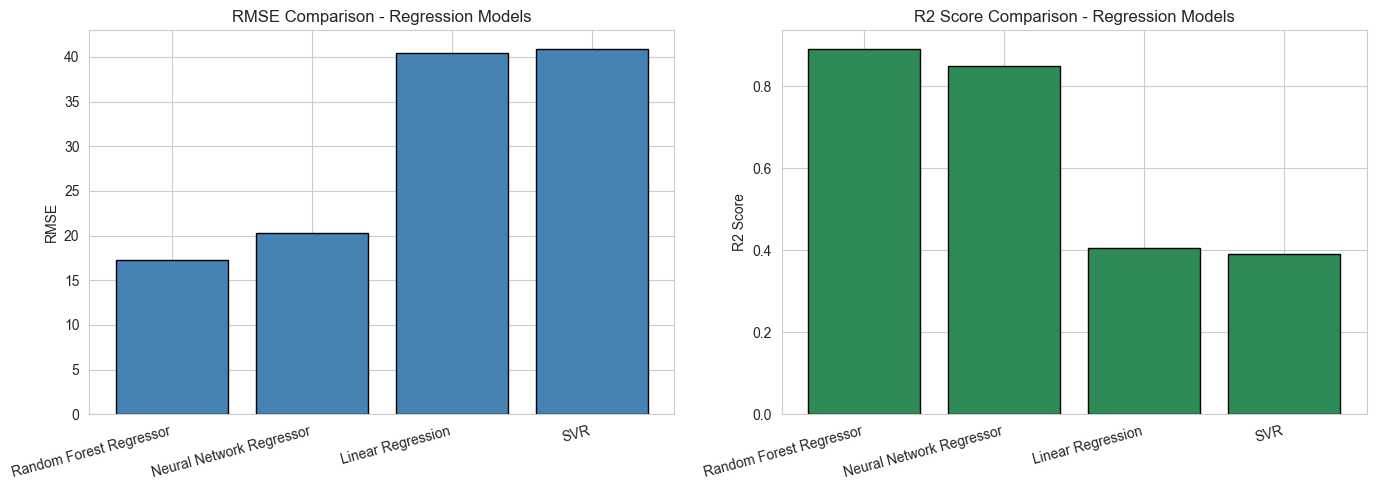

In [56]:
# Bar chart of regression metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(reg_results['Model'], reg_results['RMSE'], color='steelblue', edgecolor='black')
axes[0].set_title('RMSE Comparison - Regression Models')
axes[0].set_ylabel('RMSE')
axes[0].set_xticklabels(reg_results['Model'], rotation=15, ha='right')

axes[1].bar(reg_results['Model'], reg_results['R2 Score'], color='seagreen', edgecolor='black')
axes[1].set_title('R2 Score Comparison - Regression Models')
axes[1].set_ylabel('R2 Score')
axes[1].set_xticklabels(reg_results['Model'], rotation=15, ha='right')

plt.tight_layout()
plt.show()

## 16. Save the Best Model

In [57]:
import joblib

# Identify the best model based on F1-Score
best_model_name = results.iloc[0]['Model']
print(f'Best classification model: {best_model_name}')

# Map model name to the fitted model object
model_map = {
    'Random Forest': rf_model,
    'Decision Tree': dt_model,
    'Logistic Regression': lr_model,
    'KNN': knn_model,
    'Naive Bayes': nb_model,
    'Neural Network': mlp_model,
    'SVM': svm_model
}

best_model = model_map[best_model_name]

# Save the best model
joblib.dump(best_model, 'best_cancellation_model.pkl')
print('Best model saved as best_cancellation_model.pkl')

# Save the scaler
joblib.dump(scaler, 'scaler.pkl')
print('Scaler saved as scaler.pkl')

# Save the feature column names used during training
model_columns = X.columns.tolist()
joblib.dump(model_columns, 'model_columns.pkl')
print(f'Model columns saved as model_columns.pkl ({len(model_columns)} features)')

Best classification model: Random Forest
Best model saved as best_cancellation_model.pkl
Scaler saved as scaler.pkl
Model columns saved as model_columns.pkl (34 features)


In [58]:
# Verify the saved model by loading and predicting on a sample
loaded_model = joblib.load('best_cancellation_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')
loaded_columns = joblib.load('model_columns.pkl')

sample = X_test.iloc[:5]

# Apply scaling only for scale-sensitive models
scale_sensitive = ['Logistic Regression', 'KNN', 'SVM', 'Neural Network']
if best_model_name in scale_sensitive:
    sample_input = loaded_scaler.transform(sample)
else:
    sample_input = sample.values

sample_pred = loaded_model.predict(sample_input)
print('Sample predictions from loaded model:')
for i, pred in enumerate(sample_pred):
    status = 'Canceled' if pred == 1 else 'Not Canceled'
    print(f'  Booking {i+1}: {status}')
print('\nModel files verified and ready for GUI use.')

Sample predictions from loaded model:
  Booking 1: Not Canceled
  Booking 2: Not Canceled
  Booking 3: Not Canceled
  Booking 4: Not Canceled
  Booking 5: Not Canceled

Model files verified and ready for GUI use.


## 17. Final Conclusion and Business Recommendations

In [59]:
# Final summary of best models
best_class = results.iloc[0]
best_reg = reg_results.iloc[0]

print('=' * 60)
print('FINAL PROJECT SUMMARY')
print('=' * 60)

print('\n--- Classification Task: Cancellation Prediction ---')
print(f'Best Model: {best_class["Model"]}')
print(f'Accuracy:   {best_class["Accuracy"]:.4f}')
print(f'Precision:  {best_class["Precision"]:.4f}')
print(f'Recall:     {best_class["Recall"]:.4f}')
print(f'F1-Score:   {best_class["F1-Score"]:.4f}')

print('\n--- Regression Task: ADR Prediction ---')
print(f'Best Model: {best_reg["Model"]}')
print(f'MAE:        {best_reg["MAE"]:.4f}')
print(f'RMSE:       {best_reg["RMSE"]:.4f}')
print(f'R2 Score:   {best_reg["R2 Score"]:.4f}')
print('=' * 60)

FINAL PROJECT SUMMARY

--- Classification Task: Cancellation Prediction ---
Best Model: Random Forest
Accuracy:   0.8503
Precision:  0.7720
Recall:     0.6474
F1-Score:   0.7043

--- Regression Task: ADR Prediction ---
Best Model: Random Forest Regressor
MAE:        9.4734
RMSE:       17.2328
R2 Score:   0.8922


py -m streamlit run app.py


### Conclusions

**Classification Task - Cancellation Prediction:**

The Random Forest classifier achieved the best overall performance among all models tested. It benefits from combining multiple decision trees, which reduces overfitting and improves generalization. The most important features for predicting cancellation were lead time, deposit type, previous cancellations, and the number of special requests. Bookings with longer lead times and non-refundable deposits showed higher cancellation rates.

The PCA experiment showed that dimensionality reduction preserves a large portion of the variance with fewer components. However, the model performance was slightly reduced after PCA, indicating that the original features contain relevant discriminative information that should not be discarded.

**Regression Task - ADR Prediction:**

The Random Forest Regressor outperformed Linear Regression, SVR, and the Neural Network Regressor in predicting the Average Daily Rate. The results indicate that non-linear models are better suited for this prediction task.

**Business Recommendations:**

1. Hotels should focus overbooking strategies on bookings with high cancellation risk signals: long lead time, no deposit, and previous cancellations.
2. Encouraging customers to make special requests or choose a non-refundable deposit can reduce cancellation rates.
3. City Hotels experience a higher cancellation rate than Resort Hotels and may benefit more from predictive cancellation management.
4. Revenue management teams can use the ADR prediction model to benchmark pricing and identify bookings that are priced below or above expected rates.
5. The machine learning models trained in this project can be integrated into a booking management system to flag high-risk reservations in real time.